# Question 1 - Cat Image Classification (KNN)

### Tevyn Vergara | 46421201 | Electrical & Biomedical Engineer

DISCLAIMER: Google Gemini 3 was used for this assignment for:
1. Layout tips (all questions)
2. Syntax checking (all questions)
3. Trouble shooting and debugging
4. Functionality tips and suggestions (all questions)
5. Tips and explanation for key functions/theories and purposes
6. Re-organizing to look more modular and readable

References:
1. Google. (2026, March 17). Methods of providing alterative text for accessibility on websites. [Generative AI chat]. Gemini 3. https://gemini.google.com/


## Standard Imports for Assignment 2 ##

Please run this before executing any other cell

In [1]:
import numpy as np
import pickle   
import matplotlib.pyplot as plt
import os
from skimage import color, exposure, feature, io, transform

print('numpy', np.__version__)
print('matplotlib', plt.matplotlib.__version__)
print('pickle', pickle.format_version)

numpy 2.4.4
matplotlib 3.10.8
pickle 4.0


## NOTE: Code was ran locally as I have a dedicated GPU ##

## Question "0" - CIFAR-10 Dataset ##

Here, I'm attempting to load the images. The formatting is currently:

- Labels in batches.meta [0-9] with their respective image classes:
    0: Aeroplane
    1: Automobile
    2: Bird
    3: Cat
    4: Deer
    5: Dog
    6: Frog
    7: Horse
    8: Ship
    9: Truck

- 3072 features of flattened information --> 32 x 32 pixel images with 3 RGB channels 

- 50,000 training images split into x5 data_batch_x files (5 in total). Format: shape(10,000, 3072). So 10,000 images per batch of 3072 flattened information

To format for CNN training:
1. Use unpickle() from source: https://www.cs.toronto.edu/~kriz/cifar.html. This returns a batch dictionary of the 10,000 images, their labels, and each of their single channel information of (32x32 | 3 RGB). Their is also metadata for the batch such as the image and batch file names (Not needed for project)

2. Unload image class labels from batches.meta (0-9) and convert their byte strings to normal text for readibility. Store in meta.

3. Unload and also combine the 5 batches of training data from data_batch_x where x: [0,5]. Assuming that all the images have the same format of 
(32x32 |3 RGB), append all imagee (with their data) and their respective labels to a dictionary of arrays that contain:
    - Image data (batch[b"data"])
    - Image labels (batch[b"data"])
    - Metadata (filenames, image names) but unused


To ensure that testing data was loaded correctly, loop through the whole "batch" dataset and load the first image of each class. Display it and its respective label.



C:\Users\tevyn\AppData\Local\Temp\ipykernel_24728\3559171501.py:4: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  batch = pickle.load(fo, encoding="bytes")


X_train shape: (50000, 3072)
y_train shape: (50000,)
X_test shape: (10000, 3072)
y_test shape: (10000,)
Label names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


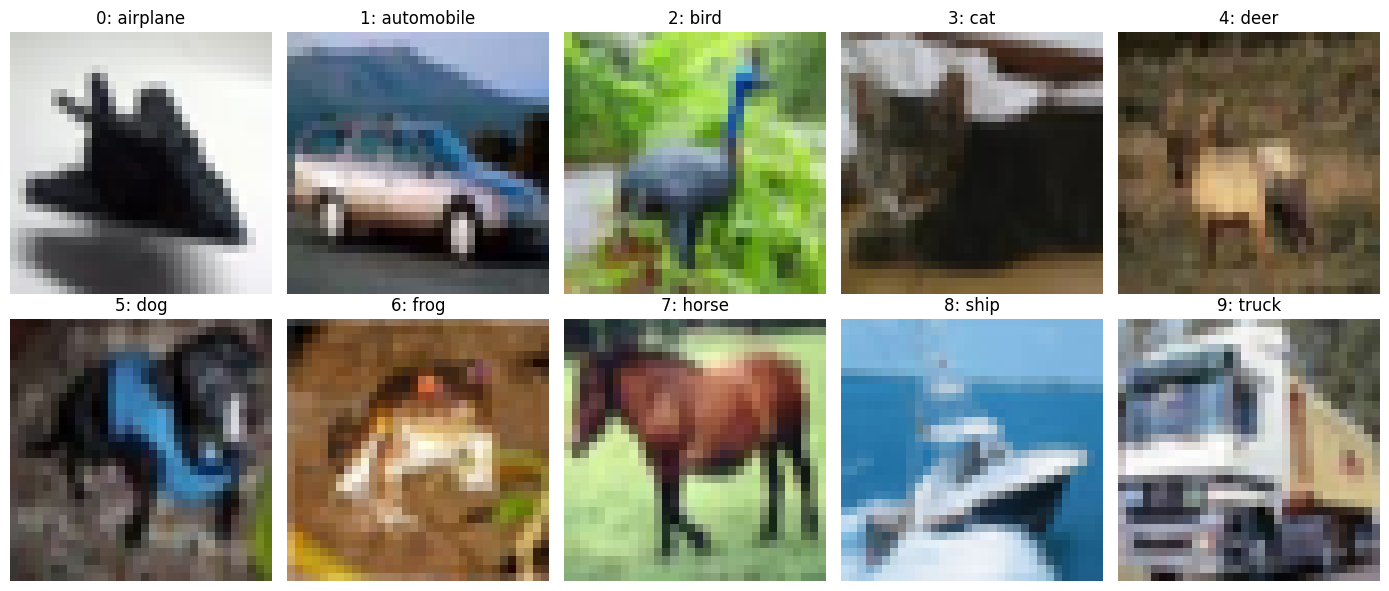

In [2]:
# Utility: read one CIFAR-10 batch/metadata pickle file from disk. From: https://www.cs.toronto.edu/~kriz/cifar.html
def unpickle(file_path):
    with open(file_path, "rb") as fo:
        batch = pickle.load(fo, encoding="bytes")
    return batch

# End-to-end loader for CIFAR-10 in the provided folder structure.
# Returns train/test images + labels, and human-readable class names.
def load_cifar10(data):
    # 1) Load class label names (airplane, automobile, etc.) from metadata.
    meta = unpickle(os.path.join(data, "batches.meta"))
    label_names = [name.decode("utf-8") for name in meta[b"label_names"]]

    # 2) Read and concatenate all 5 training batch files.
    train_images = []
    train_labels = []
    for i in range(1, 6):
        batch = unpickle(os.path.join(data, f"data_batch_{i}"))
        train_images.append(batch[b"data"])
        train_labels.extend(batch[b"labels"])

    # 3) Stack image rows into one array of shape (50000, 3072).
    X_train = np.vstack(train_images)
    y_train = np.array(train_labels, dtype=np.int64)

    # 3) Load test batch
    test_batch = unpickle(os.path.join(data, "test_batch"))
    X_test = test_batch[b"data"]
    y_test = np.array(test_batch[b"labels"], dtype=np.int64)

    return X_train, y_train, X_test, y_test, label_names

# Load the CIFAR-10 Dataset 
data = "cifar-10-batches-py"
X_train, y_train, X_test, y_test, label_names = load_cifar10(data)

# Quick shape sanity check to confirm successful parsing.
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print("Label names:", label_names)

# Visual inspection: show one example image from each class.
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for class_id, ax in enumerate(axes.ravel()):
    # Pick the first training sample for this class index.
    idx = np.where(y_train == class_id)[0][0]
    img = X_train[idx].reshape(3, 32, 32).transpose(1, 2, 0)  # (3072,) -> (32,32,3)
    ax.imshow(img)
    ax.set_title(f"{class_id}: {label_names[class_id]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

        INITIALIZING UNIFIED KNN CAT CLASSIFIER         

--- STAGE 1: CIFAR-10 TEST SET EVALUATION ---

Evaluation metrics:
Accuracy      : 0.7070
Precision     : 0.2023
Recall        : 0.6560
F1_score      : 0.3093
True_positive : 656
True_negative : 6414
False_positive: 2586
False_negative: 344


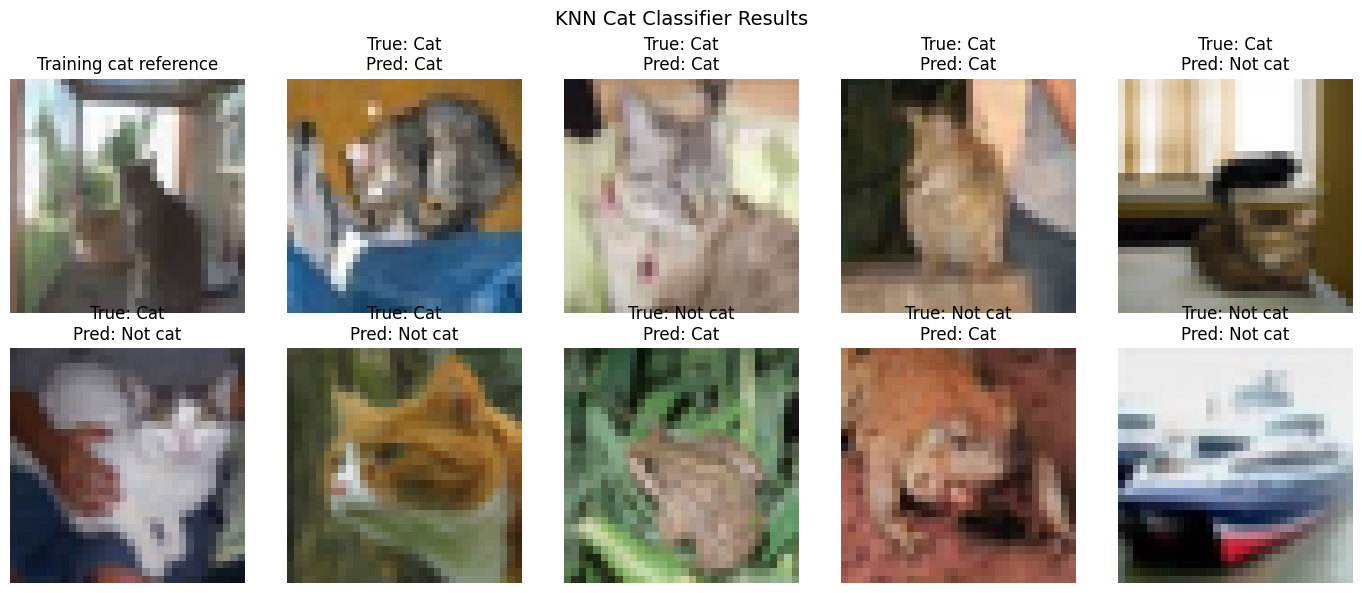


--- STAGE 2: EXTERNAL FOLDER ('cat') CLASSIFICATION ---

External Results:
  WP-Blog-Image-2022-35.jpg -> Cat
  download.jpg -> Cat


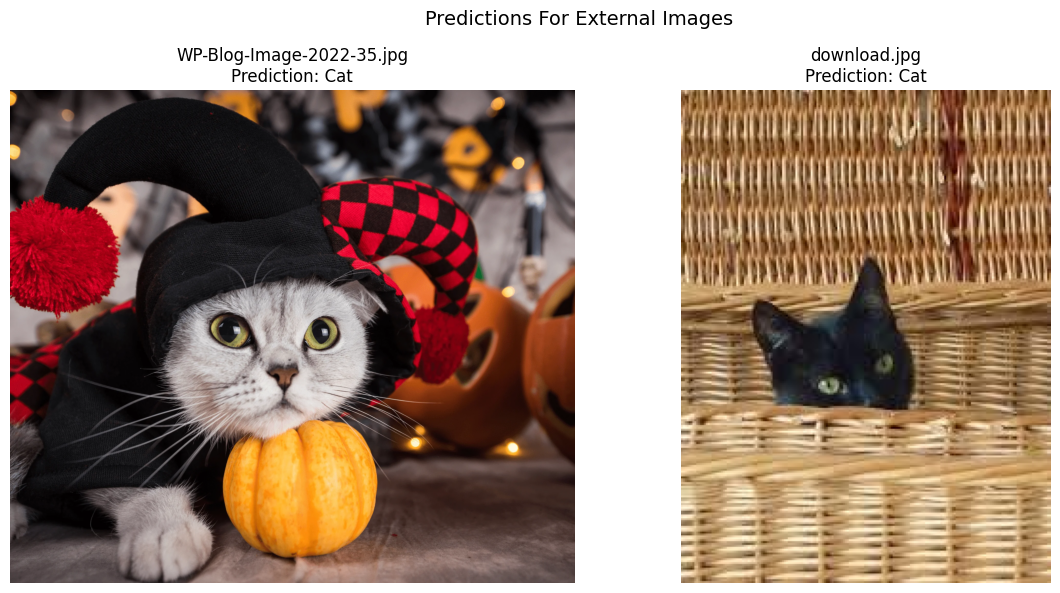

In [3]:

## Macros
CAT_CLASS_INDEX = 3
K_VALUE = 3

################################################# Helper Function Definitions #################################################
def format_cifar_for_skimage(images):
    """
    Formats CIFAR-10 data for skimage compatibility.
    Inputs: 1D or 3D image arrays.
    Outputs: Reshaped (N, 32, 32, 3) array with normalized float32 pixel values (0.0 to 1.0).
    """
    images_formatted = np.asarray(images)
    # Check if images are flattened (3072,) and reshape to standard image dimensions
    if len(images_formatted.shape) == 2:
        images_formatted = images_formatted.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
        
    # Normalize 0-255 pixel values to 0.0-1.0 to prevent skimage calculation overflow
    if images_formatted.max() > 1.0:
        images_formatted = images_formatted.astype(np.float32) / 255.0
        
    return images_formatted

def convert_to_binary_cat_labels(labels):
    """
    Converts multi-class labels into binary labels for the specific target class. Used to target cat class vs all others
    Inputs: Array of integer labels (0-9).
    Outputs: Array of binary labels (1 for Cat, 0 for Non-Cat).
    """
    return (labels == CAT_CLASS_INDEX).astype(np.int32)

def extract_image_features(images):
    """
    Extract vector from an image to capture geometry, texture, and color.
    This function combines Canny Edges, HOG, LBP and colour statistics to create feature vector for each image. 
    Found this comibination to be effective for cat/non-cat classification in preliminary testing.
    Inputs: Array of formatted images.
    Outputs: 2D array (N, num_features) containing concatenated HOG, Canny, LBP, and color metrics.
    """
    feature_vectors = []
    for image in images:

        # Convert to grayscale for texture/edge-based features
        gray_image = color.rgb2gray(image).astype(np.float32)

        # Apply Adaptive Histogram Equalization for edge detection
        equalized_gray = exposure.equalize_adapthist(gray_image, clip_limit=0.03).astype(np.float32)

        # Extract structural shape outlines using HOG (Histogram of Oriented Gradients)
        full_hog = feature.hog(equalized_gray, orientations=9, pixels_per_cell=(4, 4), cells_per_block=(2, 2), block_norm="L2-Hys", feature_vector=True)
        upper_face = equalized_gray[:20, 4:28]
        upper_hog = feature.hog(upper_face, orientations=9, pixels_per_cell=(4, 4), cells_per_block=(2, 2), block_norm="L2-Hys", feature_vector=True)

        # Extract sharp boundaries using Canny Edge detection
        edge_map = feature.canny(equalized_gray, sigma=1.0).astype(np.float32)
        whisker_band = equalized_gray[14:28, 2:30]
        whisker_edges = feature.canny(whisker_band, sigma=0.8).astype(np.float32)
        eye_band = equalized_gray[8:18, 6:26]
        
        # Extract textures (like fur patterns) using LBP (Local Binary Patterns)
        lbp = feature.local_binary_pattern((equalized_gray * 255).astype(np.uint8), P=8, R=1, method="uniform")
        lbp_histogram, _ = np.histogram(lbp, bins=np.arange(11), density=True)

        # Global color statistics
        color_means = image.mean(axis=(0, 1))
        color_stds = image.std(axis=(0, 1))
        
        # This section captures cat-like features such as eye texture, whiskers and cat facial profile
        eye_features = np.array([eye_band.mean(), eye_band.std(), eye_band.max() - eye_band.min()], dtype=np.float32)
        whisker_features = np.concatenate([np.array([whisker_edges.mean()], dtype=np.float32), whisker_edges.mean(axis=0)])
        edge_profiles = np.concatenate([edge_map.mean(axis=0), edge_map.mean(axis=1)])

        # Concetenate & combine!
        feature_vectors.append(np.concatenate([full_hog, upper_hog, edge_profiles, whisker_features, eye_features, lbp_histogram.astype(np.float32), color_means, color_stds]))

    return np.asarray(feature_vectors, dtype=np.float32)

def standardize(features, means=None, stds=None):
    """
    Standardizes feature vectors to ensure equal weighting in distance math. 
    Main purpose is to prevent leakage of feature information and ensure consistent parsing between train and test sets.
    Inputs: Features array, optional training means/stds to prevent data leakage on test sets.
    Outputs: Standardized features, means, and stds.
    """
    if means is None or stds is None:
        means = features.mean(axis=0)
        stds = features.std(axis=0) + 1e-6
    
    standardized = (features - means) / stds
    return standardized.astype(np.float32), means, stds

def l2_normalize_rows(features):
    """
    Normalizes feature vectors to unit length so Euclidean distance measures angle/pattern instead of magnitude.
    """
    norms = np.linalg.norm(features, axis=1, keepdims=True) + 1e-8
    return (features / norms).astype(np.float32)

def build_cat_focused_training_subset(binary_train_labels, non_cat_ratio=2, random_seed=42):
    """
    Balances the dataset by keeping all cats and undersampling non-cats to a defined ratio.
    Using all 50,000 images in the feature space would create massive class imbalance. There are only 5000 cat images vs 45000 non-cats
    It would significantly bias the KN voting towards non-cat predictions 
    """
    cat_indices = np.where(binary_train_labels == 1)[0]
    non_cat_indices = np.where(binary_train_labels == 0)[0]
    max_non_cat_count = min(non_cat_indices.size, cat_indices.size * non_cat_ratio)
    
    rng = np.random.default_rng(random_seed)
    sampled_non_cat_indices = rng.choice(non_cat_indices, size=max_non_cat_count, replace=False)

    subset_indices = np.concatenate([cat_indices, sampled_non_cat_indices])
    rng.shuffle(subset_indices)
    return subset_indices

def preprocess_image_for_mode(image, mode="full"):
    """
    Crops and resizes images based on view modes to enable ensemble voting.
    It allows model to focus on different parts of image not just the whole image.
    Helps cat feature extraction.
    """
    image = np.asarray(image)
    if image.ndim == 2: image = color.gray2rgb(image)
    elif image.ndim == 3 and image.shape[2] == 4: image = image[:, :, :3]

    image = image.astype(np.float32)
    if image.max() > 1.0: image /= 255.0

    height, width = image.shape[:2]

    # Crop image dynamically based on the requested focal point
    if mode == "upper_face":
        cropped_image = image[: max(int(height * 0.72), 1), int(width * 0.12) : max(int(width * 0.88), int(width * 0.12) + 1)]
    elif mode == "tight_face":
        cropped_image = image[: max(int(height * 0.62), 1), int(width * 0.18) : max(int(width * 0.82), int(width * 0.18) + 1)]
    else:
        cropped_image = image

    # Center crop to square and resize back to 32x32
    crop_size = min(cropped_image.shape[:2])
    top = (cropped_image.shape[0] - crop_size) // 2
    left = (cropped_image.shape[1] - crop_size) // 2
    cropped_image = cropped_image[top : top + crop_size, left : left + crop_size]

    resized_image = transform.resize(cropped_image, (32, 32, 3), anti_aliasing=True, preserve_range=True)
    return resized_image.astype(np.float32)

def euclidean_distance_matrix(test_batch_features, train_features, train_squared_norms):
    """
    Calculates the squared Euclidean distance efficiently using vectorization and matrix dot products.
    Inputs: Test batch, Training features, Pre-calculated training norms. 
    Outputs: The Euclidean Distance matrix.
    """
    test_squared_norms = np.sum(test_batch_features * test_batch_features, axis=1, keepdims=True)
    distances_squared = (test_squared_norms + train_squared_norms[np.newaxis, :] - 2.0 * test_batch_features @ train_features.T)
    distances_squared = np.maximum(distances_squared, 0.0)
    return np.sqrt(distances_squared, out=distances_squared)

def knn_predict(train_features, train_labels, test_features, k=3, batch_size=100, return_details=False):
    """
    Executes K-Nearest Neighbors voting based on Euclidean feature distance.
    Inputs: Train features/labels, test features, K value, and detail flag. 
    Outputs: Binary predictions array (and optionally raw cat vote counts for ensemble math).
    """
    train_features = np.ascontiguousarray(train_features.astype(np.float32))
    test_features = np.ascontiguousarray(test_features.astype(np.float32))
    train_labels = np.asarray(train_labels, dtype=np.int32)
    train_squared_norms = np.sum(train_features * train_features, axis=1)

    predictions = np.empty(test_features.shape[0], dtype=np.int32)
    if return_details:
        cat_vote_counts = np.empty(test_features.shape[0], dtype=np.int32)
        
    minimum_cat_votes = (k // 2) + 1  # Dynamic threshold for majority wins

    # Process predictions in mini-batches to prevent RAM overload
    for start_index in range(0, test_features.shape[0], batch_size):
        end_index = min(start_index + batch_size, test_features.shape[0])
        test_batch = test_features[start_index:end_index]
        
        # Calculate distances and find the 'K' closest neighbors
        distances = euclidean_distance_matrix(test_batch, train_features, train_squared_norms)
        nearest_indices = np.argpartition(distances, kth=k - 1, axis=1)[:, :k]
        nearest_labels = train_labels[nearest_indices]
        
        # Tally votes to make final binary prediction
        cat_votes = np.sum(nearest_labels, axis=1)
        predictions[start_index:end_index] = (cat_votes >= minimum_cat_votes).astype(np.int32)

        if return_details:
            cat_vote_counts[start_index:end_index] = cat_votes

    if return_details:
        return predictions, cat_vote_counts
    return predictions


######################### Metrics and Visualization Functions ###########################
def calculate_metrics(true_labels, predicted_labels):
    """
    Calculates standard classification metrics based on binary predictions.
    Inputs: Ground truth labels, Predicted labels.
    Outputs: Dictionary containing accuracy, precision, recall, f1_score, and confusion matrix counts.
    """
    # Calculate Confusion Matrix elements
    true_positive = np.sum((true_labels == 1) & (predicted_labels == 1))
    true_negative = np.sum((true_labels == 0) & (predicted_labels == 0))
    false_positive = np.sum((true_labels == 0) & (predicted_labels == 1))
    false_negative = np.sum((true_labels == 1) & (predicted_labels == 0))

    # Calculate Performance Metrics
    accuracy = (true_positive + true_negative) / true_labels.size
    
    # Using max(..., 1) or max(..., 1e-8) prevents ZeroDivisionError if a denominator is 0
    precision = true_positive / max(true_positive + false_positive, 1)
    recall = true_positive / max(true_positive + false_negative, 1)
    f1_score = 2 * precision * recall / max(precision + recall, 1e-8)

    return {
        "accuracy": accuracy, 
        "precision": precision, 
        "recall": recall, 
        "f1_score": f1_score,
        "true_positive": int(true_positive), 
        "true_negative": int(true_negative),
        "false_positive": int(false_positive), 
        "false_negative": int(false_negative)
    }

def select_example_indices(true_labels, predicted_labels, max_examples=9):
    """"
    This function selects test examples to display
    Mixes true positives, false negatives, false positives, and true negatives to provide a balanced visual overview of model performance.
    """
    true_positive = np.where((true_labels == 1) & (predicted_labels == 1))[0]
    false_negative = np.where((true_labels == 1) & (predicted_labels == 0))[0]
    false_positive = np.where((true_labels == 0) & (predicted_labels == 1))[0]
    true_negative = np.where((true_labels == 0) & (predicted_labels == 0))[0]

    selected_indices = []
    groups = (true_positive[:3], false_negative[:3], false_positive[:2], true_negative[:2])

    for group in groups:
        for index in group:
            if len(selected_indices) == max_examples: return selected_indices
            selected_indices.append(int(index))
            
    return selected_indices

def plot_results(reference_cat_image, test_images, true_labels, predicted_labels, max_examples=9):
    """
    Plots a reference cat image alongside a selection of test images with their true and predicted labels.

    """
    example_indices = select_example_indices(true_labels, predicted_labels, max_examples=max_examples)
    figure, axes = plt.subplots(2, 5, figsize=(14, 6))
    axes = axes.ravel()

    axes[0].imshow(np.clip(reference_cat_image, 0.0, 1.0))
    axes[0].set_title("Training cat reference")
    axes[0].axis("off")

    for axis, image_index in zip(axes[1:], example_indices):
        axis.imshow(test_images[image_index])
        axis.set_title(f"True: {'Cat' if true_labels[image_index] == 1 else 'Not cat'}\nPred: {'Cat' if predicted_labels[image_index] == 1 else 'Not cat'}")
        axis.axis("off")

    for axis in axes[len(example_indices) + 1 :]:
        axis.axis("off")

    figure.suptitle("KNN Cat Classifier Results", fontsize=14)
    plt.tight_layout()
    plt.show()

def plot_external_classification_results(images, results):
    """
    Plots the external images with their binary prediction.
    Updated to only look for 'image_name' and 'predicted_label'.
    """
    figure, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 6))
    if len(results) == 1: axes = [axes]

    for axis, image, result in zip(axes, images, results):
        axis.imshow(np.clip(image, 0.0, 1.0))
        # FIX: Removed the calls to the deleted 'cat_votes' and 'view_predictions' keys
        axis.set_title(f"{result['image_name']}\nPrediction: {result['predicted_label']}")
        axis.axis("off")

    figure.suptitle("Predictions For External Images", fontsize=14)
    plt.tight_layout()
    plt.show()

def load_images_from_folder(folder_path):
    """
    Scans a local directory for images, reads them, and normalizes their color channels.
    Inputs: String path to the target folder (e.g., "cats").
    Outputs: A list of filenames and a list of normalized image arrays.
    """
    image_names = []
    original_images = []
    # Explicitly check for standard image formats, including your .jpg files
    valid_extensions = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")

    # Safety check: Does the folder actually exist in this directory?
    if not os.path.exists(folder_path):
        print(f"Warning: The folder '{folder_path}' could not be found.")
        return image_names, original_images

    # Iterate through all files in the folder
    for file_name in sorted(os.listdir(folder_path)):
        file_path = os.path.join(folder_path, file_name)
        
        if os.path.isfile(file_path) and file_name.lower().endswith(valid_extensions):
            image_names.append(file_name)
            
            # Read the image array
            img = np.asarray(io.imread(file_path))
            
            # Ensure the image is strictly 3-channel RGB
            if img.ndim == 2: 
                img = color.gray2rgb(img)
            elif img.ndim == 3 and img.shape[2] == 4: 
                img = img[:, :, :3] # Strip alpha (transparency) channel if present
                
            # Normalize pixel values to 0.0 - 1.0 for processing
            if img.max() > 1.0: 
                img = img.astype(np.float32) / 255.0
                
            original_images.append(img)

    return image_names, original_images

################################################# Main KNN Cat Classifer #################################################
def cat_knn_classifier(X_train, y_train, X_test, y_test, external_folder="cat", train_limit=None, test_limit=None, non_cat_ratio=1, show_plots=True):
    """
    Main function to execute the unified KNN Cat Classifier pipeline.
    Trains using the training CIFAR-10 dataset
    Evalutes on the CIFAR-10 test set 
    Classifies the two cat images in the "cat" folder using 3 different zoom levels
    """
    print("========================================================")
    print("        INITIALIZING UNIFIED KNN CAT CLASSIFIER         ")
    print("========================================================")
    
    # Format CIFAR-10 training and test sets for skimage processing
    train_images, train_labels = format_cifar_for_skimage(X_train), np.asarray(y_train)
    test_images, test_labels = format_cifar_for_skimage(X_test), np.asarray(y_test)

    # Convert to binary labels to focus on cat vs non-cat classification
    binary_train_labels, binary_test_labels = convert_to_binary_cat_labels(train_labels), convert_to_binary_cat_labels(test_labels)
    subset_indices = build_cat_focused_training_subset(binary_train_labels, non_cat_ratio=non_cat_ratio)

    # Build training subset with all cats and non-cats
    train_images, binary_train_labels = train_images[subset_indices], binary_train_labels[subset_indices]

    # Evaluate model on CIFAR-10 test set to confirm performance
    print("\n--- STAGE 1: CIFAR-10 TEST SET EVALUATION ---")
    train_processed = np.asarray([preprocess_image_for_mode(img, mode="full") for img in train_images], dtype=np.float32)
    test_processed = np.asarray([preprocess_image_for_mode(img, mode="full") for img in test_images], dtype=np.float32)
    
    # Extract features from original full images to reuse for external classification stage and save time
    raw_train_features_full = extract_image_features(train_processed)
    test_features = extract_image_features(test_processed)

    # Standardize & Normalize using calculated training means/stds
    # Apply also to test set
    train_features_std, means, stds = standardize(raw_train_features_full)
    test_features_std, _, _ = standardize(test_features, means, stds)
    train_features_norm, test_features_norm = l2_normalize_rows(train_features_std), l2_normalize_rows(test_features_std)

    # Execute predictions and evaluate Test Accuracy
    test_predictions = knn_predict(train_features_norm, binary_train_labels, test_features_norm, k=K_VALUE)
    metrics = calculate_metrics(binary_test_labels, test_predictions)
    
    print("\nEvaluation metrics:")
    for key, val in metrics.items(): print(f"{key.capitalize():<14}: {val:.4f}" if isinstance(val, float) else f"{key.capitalize():<14}: {val}")
    if show_plots: plot_results(train_processed[np.where(binary_train_labels == 1)[0][0]], test_images, binary_test_labels, test_predictions)

    # CLASSIFICATION OF EXTERNAL CAT IMAGES
    print(f"\n--- STAGE 2: EXTERNAL FOLDER ('{external_folder}') CLASSIFICATION ---")
    image_names, original_images = load_images_from_folder(external_folder)
    if not original_images: return metrics, []

    view_modes = ("full", "upper_face", "tight_face")

    # Initialize predictors and vote counts for ensemble tallying (KNN based theory)
    aggregated_predictions, aggregated_cat_votes = np.zeros(len(image_names), dtype=np.int32), np.zeros(len(image_names), dtype=np.int32)

    # Ensemble Loop: Extracts features for 3 different zoom depths to mitigate background noise
    for view_mode in view_modes:
        ext_view_images = np.asarray([preprocess_image_for_mode(io.imread(os.path.join(external_folder, name)), mode=view_mode) for name in image_names], dtype=np.float32)
        ext_features = extract_image_features(ext_view_images)
        
        # Reuse 'full' features from Stage 1 to heavily optimize processing time
        if view_mode == "full": view_train_features = raw_train_features_full
        else:

            # Extract features for the current view mode to enable viewing of different zoom levels
            view_train_images = np.asarray([preprocess_image_for_mode(img, mode=view_mode) for img in train_images], dtype=np.float32)
            view_train_features = extract_image_features(view_train_images)
            
        # Standardize & Normalize extracted features using training parameters
        view_train_std, view_means, view_stds = standardize(view_train_features)
        ext_features_std, _, _ = standardize(ext_features, view_means, view_stds)
        view_train_norm, ext_features_norm = l2_normalize_rows(view_train_std), l2_normalize_rows(ext_features_std)

        # Retrieve raw vote counts from KNN for ensemble tallying
        preds, votes = knn_predict(view_train_norm, binary_train_labels, ext_features_norm, k=K_VALUE, return_details=True)
        aggregated_predictions += preds; aggregated_cat_votes += votes

    print("\nExternal Results:")
    ext_results = []
    for i, name in enumerate(image_names):
        # Ensemble Rule: Needs to win 2 views OR gather 4 total raw votes across all views
        final_prediction = "Cat" if (aggregated_predictions[i] >= 2 or aggregated_cat_votes[i] >= 4) else "Not cat"
        ext_results.append({"image_name": name, "predicted_label": final_prediction})
        print(f"  {name} -> {final_prediction}")

    if show_plots: plot_external_classification_results(original_images, ext_results)
    return metrics, ext_results

################################################# Run it back #################################################
metrics, external_results = cat_knn_classifier(X_train, y_train, X_test, y_test, external_folder="cat", show_plots=True)

## Algorithm Configuration & Theoretical Justification

**K=3**

Odd numbers avoid ties in binary classification. K=1 is too noisy — one bad training example poisons the prediction. K=15 over-smooths and loses the local structure that distinguishes cats from everything else. Three is the sweet spot.

**Euclidean Distance**

L2 normalization makes Euclidean distance and Cosine Similarity mathematically equivalent here. Normalizing to unit length cancels out brightness and contrast differences, so what's actually being measured is the *angle* between feature patterns — orientation, not magnitude.

**Raw Pixels**

KNN has no training phase — it just memorizes examples and votes at inference time. That means the features have to carry all the meaning. Raw pixels don't; lighting alone makes the same cat look completely different numerically. HOG captures shape, LBP captures texture, Canny captures edges — together they give the distance function something geometrically meaningful to compare.

## External Testing Results, Challenges, & Solutions

**How It Was Tested**

Rather than feeding each image to the classifier whole, the pipeline splits it into three crops — full frame, upper face, and tight face — extracts features from each, and combines the votes. This keeps background noise from drowning out the actual facial features.

**What Went Wrong**

Real-world images exposed three recurring failure modes:

- **Lighting.** Harsh sunlight and artificial indoor light shift color distributions and cast shadows that HOG and Canny misread as real edges, generating phantom shapes.
- **Background clutter.** At 32×32 pixels, a cat in a grassy field is mostly grass. The dense LBP texture of the background can dominate the distance calculation, causing the model to match on environment rather than subject.
- **Pose and scale.** HOG slices the image into fixed spatial bins. A cat curled up or photographed close-up lands its features in completely different bins than a cat standing upright in training data — the spatial correlation breaks.

**How to Fix It**

- **SIFT/SURF keypoints** replace rigid HOG grids with location-independent descriptors, making feature detection robust to zoom and rotation.
- **Data augmentation** — varying brightness, contrast, and orientation during training — gives the model more diverse neighbors to vote from, reducing sensitivity to lighting conditions.
- **CNNs** are the real long-term fix. Rather than hand-engineering features, a convolutional network learns what to look for automatically, building shift-invariant representations that naturally ignore irrelevant backgrounds.